# 01 — Exploratory Data Analysis

**Dataset:** IEEE-CIS Fraud Detection (Kaggle competition, data provided by Vesta Corporation).
Real, anonymized e-commerce transactions — **not synthetic**. `train_transaction.csv` (394 columns)
is joined to `train_identity.csv` (41 columns) on `TransactionID`.

Many columns (`C1-C14`, `D1-D15`, `M1-M9`, `V1-V339`, most `id_*`) are intentionally masked by
Vesta. This notebook treats them as opaque model inputs and never assigns them invented
real-world meaning — only documented columns (amount, product, card network/type, email domain,
device, address/distance, time) get business interpretation.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 4)

tx = pd.read_csv("../data/raw/train_transaction.csv")
idn = pd.read_csv("../data/raw/train_identity.csv")
df = tx.merge(idn, on="TransactionID", how="left")
print(f"transactions: {len(tx):,}   identity rows: {len(idn):,}   merged: {len(df):,}")
print(f"identity match rate: {len(idn)/len(tx):.1%}")

transactions: 590,540   identity rows: 144,233   merged: 590,540
identity match rate: 24.4%


## Overall fraud rate

In [2]:
fraud_counts = df["isFraud"].value_counts(normalize=True).rename({0: "legitimate", 1: "fraud"})
print(fraud_counts)
print(f"\nTotal transactions: {len(df):,}")
print(f"Fraud transactions: {df['isFraud'].sum():,}")
print(f"Total fraud value: ${df.loc[df.isFraud==1, 'TransactionAmt'].sum():,.0f}")
print(f"Avg fraud amount: ${df.loc[df.isFraud==1, 'TransactionAmt'].mean():,.2f}  |  Median: ${df.loc[df.isFraud==1, 'TransactionAmt'].median():,.2f}")
print(f"Avg legit amount: ${df.loc[df.isFraud==0, 'TransactionAmt'].mean():,.2f}  |  Median: ${df.loc[df.isFraud==0, 'TransactionAmt'].median():,.2f}")

isFraud
legitimate    0.96501
fraud         0.03499
Name: proportion, dtype: float64

Total transactions: 590,540
Fraud transactions: 20,663
Total fraud value: $3,083,845
Avg fraud amount: $149.24  |  Median: $75.00
Avg legit amount: $134.51  |  Median: $68.50


## Fraud rate by transaction type / card

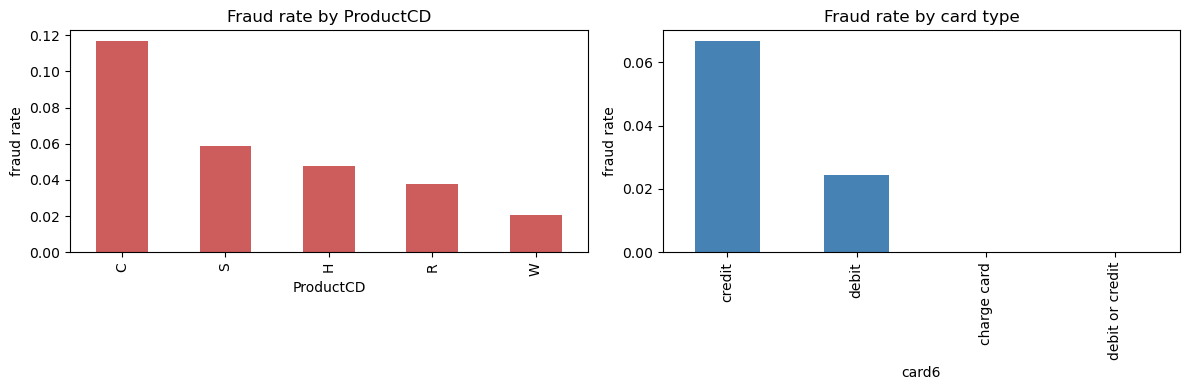

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], title="Fraud rate by ProductCD", color="indianred")
axes[0].set_ylabel("fraud rate")

df.groupby("card6")["isFraud"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], title="Fraud rate by card type", color="steelblue")
axes[1].set_ylabel("fraud rate")
plt.tight_layout()
plt.show()

## Amount distribution: fraud vs. legitimate

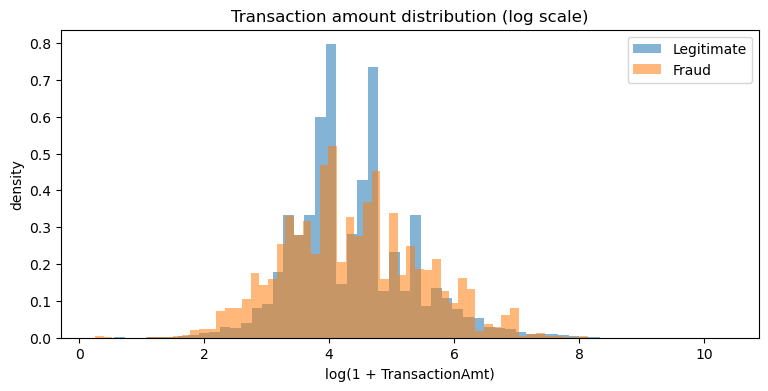

In [4]:
fig, ax = plt.subplots()
for label, sub in df.groupby("isFraud"):
    ax.hist(np.log1p(sub["TransactionAmt"]), bins=60, alpha=0.55,
            label="Fraud" if label else "Legitimate", density=True)
ax.set_xlabel("log(1 + TransactionAmt)")
ax.set_ylabel("density")
ax.set_title("Transaction amount distribution (log scale)")
ax.legend()
plt.show()

## Fraud over time

`TransactionDT` is seconds elapsed from an arbitrary reference point (not a calendar timestamp), but it's a valid ordering/day-bucketing key.

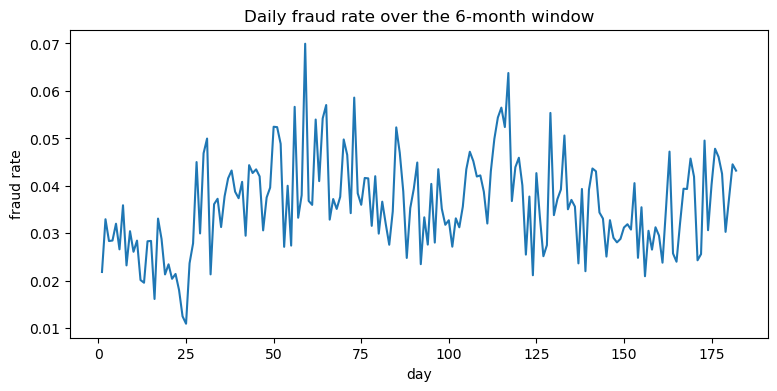

In [5]:
df["transaction_day"] = df["TransactionDT"] // (24*60*60)
daily = df.groupby("transaction_day")["isFraud"].agg(["count", "sum"])
daily["rate"] = daily["sum"] / daily["count"]

fig, ax = plt.subplots()
ax.plot(daily.index, daily["rate"])
ax.set_xlabel("day"); ax.set_ylabel("fraud rate"); ax.set_title("Daily fraud rate over the 6-month window")
plt.show()

## Missingness in masked feature blocks

A well-known property of this dataset: the V-block has large, block-structured missingness driven by which Vesta feature group applies to a given product/entity.

In [6]:
v_cols = [c for c in df.columns if c.startswith("V")]
id_cols = [c for c in df.columns if c.startswith("id_")]
c_cols = [c for c in df.columns if c.startswith("C")]
d_cols = [c for c in df.columns if c.startswith("D")]

print(f"V columns: {len(v_cols)}, avg missing rate: {df[v_cols].isna().mean().mean():.1%}")
print(f"id_ columns: {len(id_cols)}, avg missing rate: {df[id_cols].isna().mean().mean():.1%} (only {len(idn)/len(tx):.1%} of txns have any identity row)")
print(f"C columns: {len(c_cols)}, avg missing rate: {df[c_cols].isna().mean().mean():.1%}")
print(f"D columns: {len(d_cols)}, avg missing rate: {df[d_cols].isna().mean().mean():.1%}")

V columns: 339, avg missing rate: 43.0%


id_ columns: 38, avg missing rate: 84.8% (only 24.4% of txns have any identity row)
C columns: 14, avg missing rate: 0.0%
D columns: 17, avg missing rate: 60.5%


## Email domain and device signals

These ARE documented, interpretable columns — good candidates for investigator-facing reason codes.

In [7]:
email_fraud = df.groupby("P_emaildomain")["isFraud"].agg(["count", "mean"]).query("count > 500").sort_values("mean", ascending=False)
print("Top purchaser email domains by fraud rate (min 500 txns):")
print(email_fraud.head(10))

print("\nFraud rate by device type:")
print(df.groupby("DeviceType")["isFraud"].mean())

Top purchaser email domains by fraud rate (min 500 txns):
                count      mean
P_emaildomain                  
mail.com          559  0.189624
outlook.com      5096  0.094584
live.com.mx       749  0.054740
hotmail.com     45250  0.052950
gmail.com      228355  0.043542
icloud.com       6267  0.031434
comcast.net      7888  0.031187
charter.net       816  0.030637
bellsouth.net    1909  0.027763
live.com         3041  0.027622

Fraud rate by device type:
DeviceType
desktop    0.065215
mobile     0.101662
Name: isFraud, dtype: float64


## Takeaways for feature engineering

- Fraud is rare (~3.5%) and concentrated in certain `ProductCD` / card-type / email-domain combinations — supports interpretable business features.
- The identity table only covers ~24% of transactions; "has identity data" is itself a usable signal.
- Masked C/D/M/V blocks carry real predictive signal (see 03_modeling SHAP results) but are used as opaque numeric inputs, never given invented meaning.
- `TransactionDT` supports both time-of-day/day-of-week features and a chronological train/test split.

Next: `02_feature_engineering.ipynb`.